<a href="https://colab.research.google.com/github/riteshghosh01/Predictive-Analytics-Project-Ritesh/blob/main/Final_Project_Predictive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Hospital** Readmissions Analysis (30,000 Patients)

This notebook performs a comprehensive Exploratory Data Analysis (EDA), visualisation, and predictive modelling on a hospital readmission dataset containing 30,000 patient records.

# **1. Importing Libraries**

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn import tree



This cell imports all necessary libraries for data manipulation, visualization, and machine learning tasks.
It includes `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn` modules.

# **2. Dataset Loading**


In [39]:
df = pd.read_csv("/content/hospital_readmissions_30k.csv")
df.head(10)

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
5,6,75,Female,139/100,194,33.5,No,Yes,0,10,Home,No
6,7,47,Male,139/79,168,27.1,No,Yes,5,8,Home,No
7,8,18,Other,153/81,210,26.3,No,No,5,2,Home,No
8,9,68,Male,111/76,218,30.4,No,Yes,3,8,Home,No
9,10,23,Female,142/72,186,21.3,No,No,3,3,Home,No


This code loads the `hospital_readmissions_30k.csv` dataset into a pandas DataFrame.
It then displays the first 10 rows to provide an initial look at the data structure.

In [40]:
df

,patient_id,age,gender,blood_pressure,cholesterol,bmi,diabetes,hypertension,medication_count,length_of_stay,discharge_destination,readmitted_30_days
0,1,74,Other,130/72,240,31.5,Yes,No,5,1,Nursing_Facility,Yes
1,2,46,Female,120/92,292,36.3,No,No,4,3,Nursing_Facility,No
2,3,89,Other,135/78,153,30.3,No,Yes,1,1,Home,No
3,4,84,Female,123/80,153,31.5,No,Yes,3,10,Home,No
4,5,32,Other,135/84,205,18.4,No,Yes,6,4,Nursing_Facility,No
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,29,Male,112/80,157,31.4,No,No,4,10,Home,Yes
29996,29997,20,Other,146/83,198,30.2,No,Yes,4,1,Home,Yes
29997,29998,40,Other,131/96,275,23.3,Yes,Yes,7,2,Home,No
29998,29999,61,Other,124/75,232,34.3,No,No,5,3,Home,No


This cell displays the entire DataFrame `df`.
It allows reviewing all rows and columns loaded from the CSV file.

In [41]:
df.info()
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             30000 non-null  int64  
 1   age                    30000 non-null  int64  
 2   gender                 30000 non-null  object 
 3   blood_pressure         30000 non-null  object 
 4   cholesterol            30000 non-null  int64  
 5   bmi                    30000 non-null  float64
 6   diabetes               30000 non-null  object 
 7   hypertension           30000 non-null  object 
 8   medication_count       30000 non-null  int64  
 9   length_of_stay         30000 non-null  int64  
 10  discharge_destination  30000 non-null  object 
 11  readmitted_30_days     30000 non-null  object 
dtypes: float64(1), int64(5), object(6)
memory usage: 2.7+ MB
Dataset shape: 30,000 rows × 12 columns


This code provides a concise summary of the DataFrame, including data types and non-null values.
It also prints the total number of rows and columns in the dataset.

# **3. Descriptive Statistics**

In [42]:
df.describe()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,53.884233,225.260400,28.946263,5.012267,5.502900
std,8660.398374,21.056485,43.585671,6.348204,3.166383,2.867298
min,1.000000,18.000000,150.000000,18.000000,0.000000,1.000000
25%,7500.750000,36.000000,188.000000,23.400000,2.000000,3.000000
50%,15000.500000,54.000000,225.000000,28.900000,5.000000,5.000000
75%,22500.250000,72.000000,263.000000,34.500000,8.000000,8.000000
max,30000.000000,90.000000,300.000000,40.000000,10.000000,10.000000


This cell generates descriptive statistics for numerical columns in the DataFrame.
It shows central tendency, dispersion, and shape of the distribution of a dataset.

In [43]:
df.select_dtypes(include=np.number).corr()

,patient_id,age,cholesterol,bmi,medication_count,length_of_stay
patient_id,1.000000,8.717139e-04,-0.003111,-0.002473,-0.003860,3.838647e-03
age,0.000872,1.000000e+00,-0.005183,0.009136,0.001969,-7.885948e-07
cholesterol,-0.003111,-5.182663e-03,1.000000,-0.004181,-0.000590,2.734638e-03
bmi,-0.002473,9.136121e-03,-0.004181,1.000000,0.006086,-1.560990e-03
medication_count,-0.003860,1.968683e-03,-0.000590,0.006086,1.000000,8.495865e-03
length_of_stay,0.003839,-7.885948e-07,0.002735,-0.001561,0.008496,1.000000e+00


This code calculates the correlation matrix for all numerical features in the DataFrame.
It helps to understand the linear relationships between different numerical variables.

In [44]:
dup = df.duplicated().sum()
print(f"Duplicate rows: {dup}")

Duplicate rows: 0


This cell checks for and counts any duplicate rows present in the dataset.
It's an important step in data cleaning to ensure data uniqueness.

# **4. Data Cleaning**

In [45]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"Total missing cells: {df.isnull().sum().sum()}")

Missing values per column:
patient_id               0
age                      0
gender                   0
blood_pressure           0
cholesterol              0
bmi                      0
diabetes                 0
hypertension             0
medication_count         0
length_of_stay           0
discharge_destination    0
readmitted_30_days       0
dtype: int64
Total missing cells: 0


This code identifies and reports the number of missing values for each column.
It also calculates the total number of missing cells across the entire dataset.

In [67]:
# Parse systolic & diastolic BP from 'blood_pressure' column
df[["bp_systolic", "bp_diastolic"]] = df["blood_pressure"].str.split("/", expand=True).astype(int)
print("Blood pressure split ")
df[["blood_pressure", "bp_systolic", "bp_diastolic"]].head()

Blood pressure split 


,blood_pressure,bp_systolic,bp_diastolic
0,130/72,130,72
1,120/92,120,92
2,135/78,135,78
3,123/80,123,80
4,135/84,135,84


This cell parses the 'blood_pressure' column to extract systolic and diastolic values into new integer columns.
It then displays the first few rows of the original and new blood pressure columns.

# **5. Categorical Feature Counts**

In [47]:
cat_cols = ["gender", "diabetes", "hypertension", "discharge_destination", "readmitted_30_days"]

print("Value Counts for Categorical Features:")
for col in cat_cols:
    print(f"─── {col} ───")
    print(df[col].value_counts())
    print()

Value Counts for Categorical Features:
─── gender ───
gender
Male      10097
Other     10024
Female     9879
Name: count, dtype: int64

─── diabetes ───
diabetes
No     15051
Yes    14949
Name: count, dtype: int64

─── hypertension ───
hypertension
No     15022
Yes    14978
Name: count, dtype: int64

─── discharge_destination ───
discharge_destination
Home                20877
Rehab                6096
Nursing_Facility     3027
Name: count, dtype: int64

─── readmitted_30_days ───
readmitted_30_days
No     26326
Yes     3674
Name: count, dtype: int64



This code iterates through specified categorical columns and prints the value counts for each.
It provides a frequency distribution for categories within these features.

# **6. Correlation Matrix**

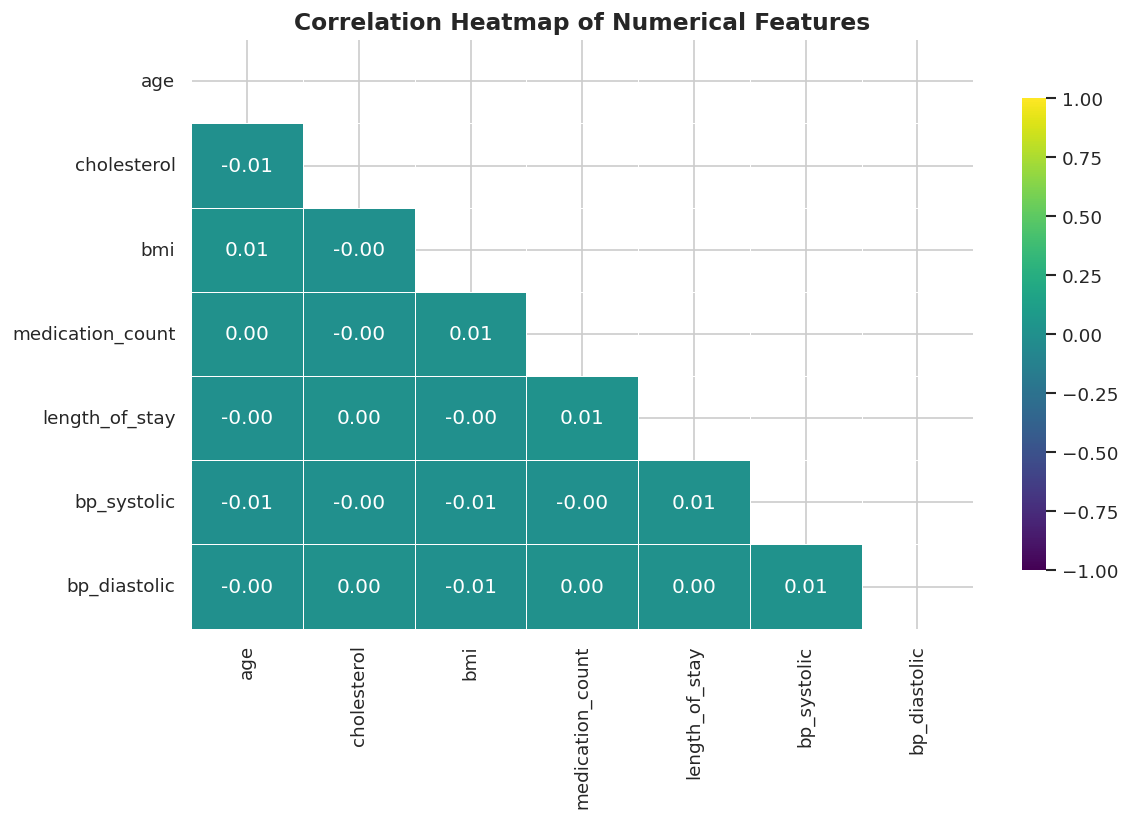

In [48]:
plt.figure(figsize=(10, 7))
corr = df.select_dtypes(include=np.number).drop(columns=["patient_id"]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis",
            mask=mask, linewidths=0.5, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap of Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

This cell generates and displays a heatmap of the correlation matrix for numerical features.
It visually represents the strength and direction of linear relationships between variables.

# **7. Data Visualisation**

## 7.1 Overall 30-Day Readmission Rate

/tmp/ipykernel_3860/1166091948.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="readmitted_30_days", y="count", data=counts, palette=["#E74C3C", "#2ECC71"])


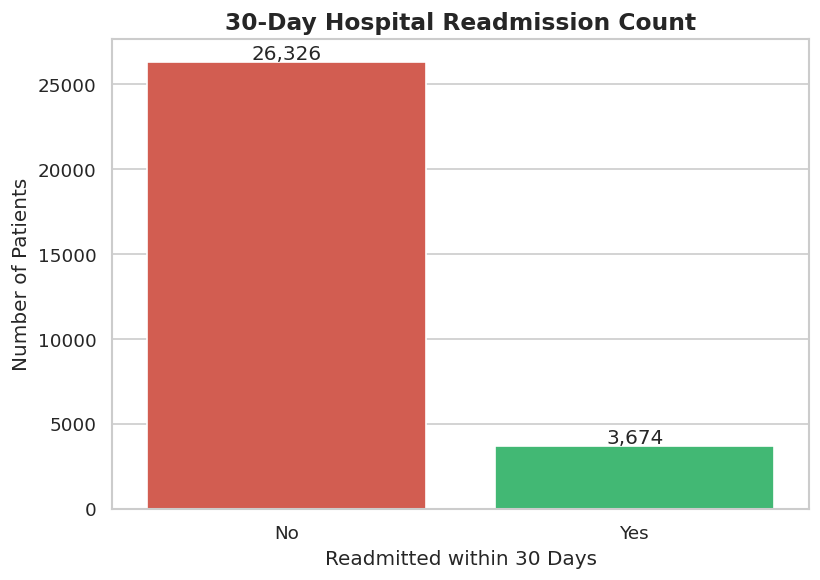

In [49]:
counts = df["readmitted_30_days"].value_counts().reset_index()
counts.columns = ["readmitted_30_days", "count"]

plt.figure(figsize=(7, 5))
ax = sns.barplot(x="readmitted_30_days", y="count", data=counts, palette=["#E74C3C", "#2ECC71"])
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 150,
            f"{int(bar.get_height()):,}", ha="center", fontsize=12)
plt.title("30-Day Hospital Readmission Count", fontsize=14, fontweight="bold")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

This code creates a bar plot showing the total counts of patients readmitted and not readmitted within 30 days.
It provides an overview of the readmission rate in the dataset.

## 7.2 Gender Distribution (Pie Chart)

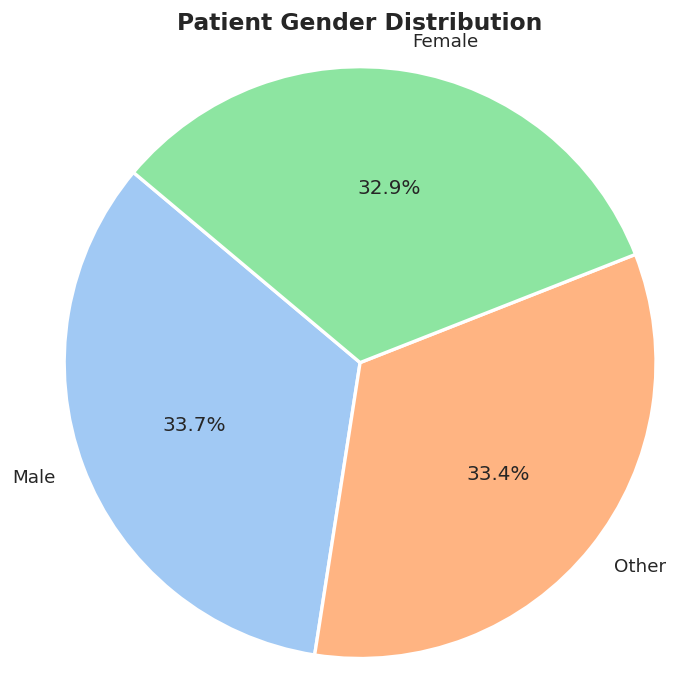

In [50]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(7, 7))
colors = sns.color_palette("pastel")
plt.pie(gender_counts, labels=gender_counts.index, autopct="%1.1f%%",
        startangle=140, colors=colors, wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Patient Gender Distribution", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.show()

This cell generates a pie chart illustrating the distribution of patient genders.
It shows the proportion of Male, Female, and Other genders in the dataset.

## 7.3 Age Distribution

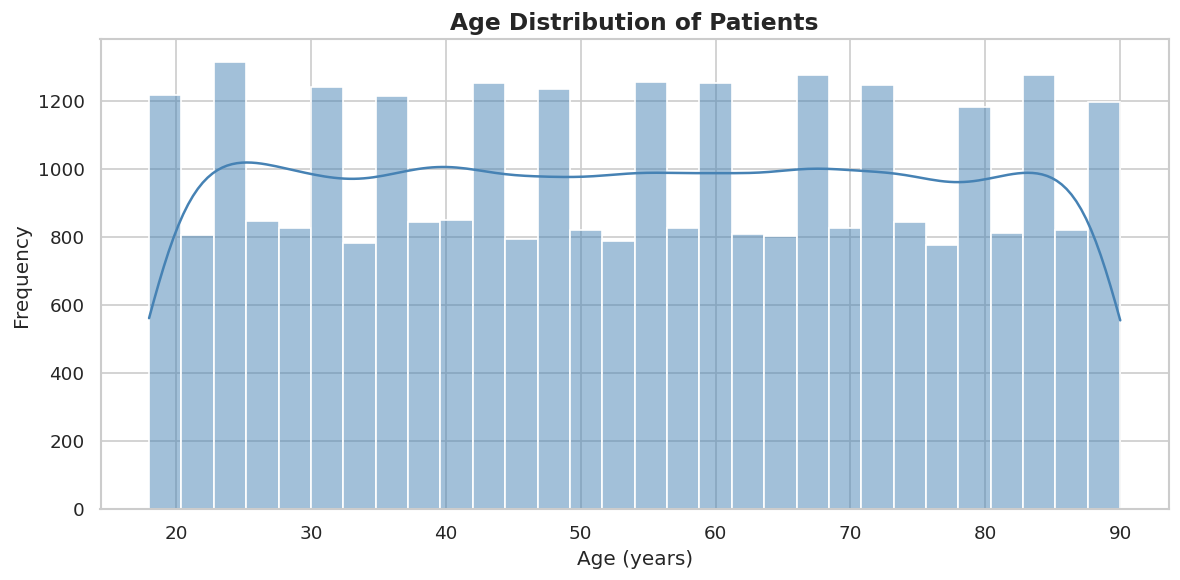

In [51]:
plt.figure(figsize=(10, 5))
sns.histplot(df["age"], bins=30, kde=True, color="steelblue", edgecolor="white")
plt.title("Age Distribution of Patients", fontsize=14, fontweight="bold")
plt.xlabel("Age (years)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

This code creates a histogram to visualize the distribution of patient ages.
It helps in understanding the age demographics of the patient population.

## 7.4 BMI vs Length of Stay (coloured by Readmission)

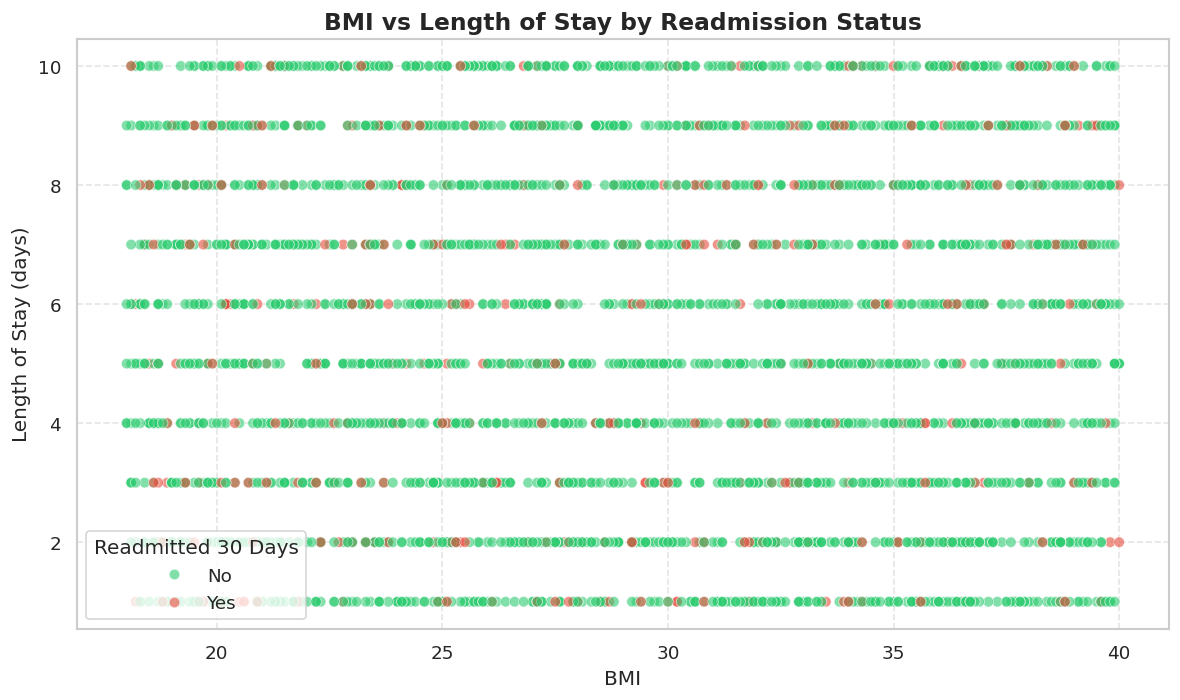

In [52]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x="bmi", y="length_of_stay", hue="readmitted_30_days",
                data=df.sample(3000, random_state=42),
                alpha=0.6, s=40, palette={"Yes": "#E74C3C", "No": "#2ECC71"})
plt.title("BMI vs Length of Stay by Readmission Status", fontsize=14, fontweight="bold")
plt.xlabel("BMI")
plt.ylabel("Length of Stay (days)")
plt.legend(title="Readmitted 30 Days")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

This cell generates a scatter plot showing the relationship between BMI and Length of Stay.
The points are colored by readmission status, highlighting potential patterns.

## 7.5 Discharge Destination Distribution

/tmp/ipykernel_3860/1298836277.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="discharge_destination", y="count", data=dest_counts, palette="viridis")


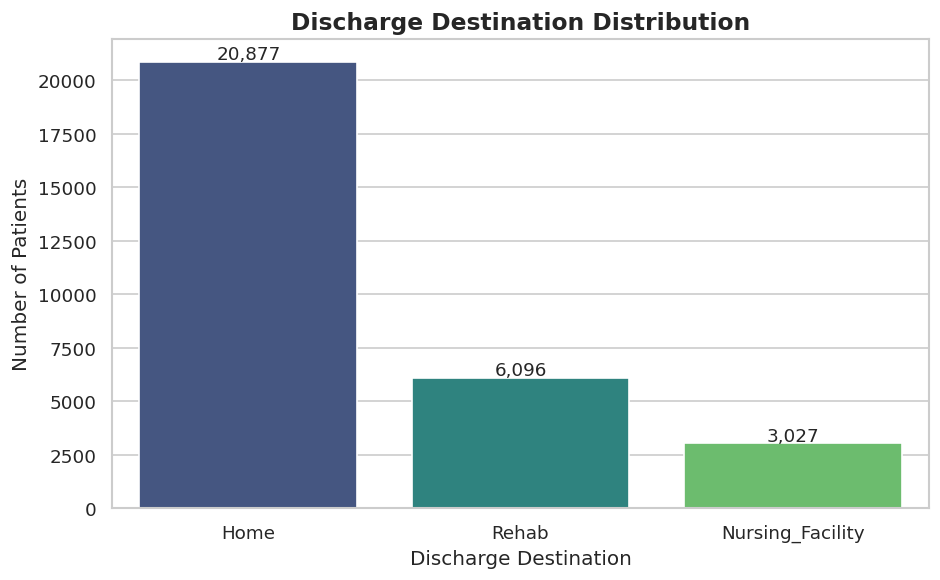

In [53]:
dest_counts = df["discharge_destination"].value_counts().reset_index()
dest_counts.columns = ["discharge_destination", "count"]

plt.figure(figsize=(8, 5))
ax = sns.barplot(x="discharge_destination", y="count", data=dest_counts, palette="viridis")
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
            f"{int(bar.get_height()):,}", ha="center", fontsize=11)
plt.title("Discharge Destination Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Discharge Destination")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.show()

This code creates a bar plot showing the distribution of patients across different discharge destinations.
It indicates where patients are typically discharged to after their hospital stay.

## 7.6 Readmission Rate by Diabetes & Hypertension

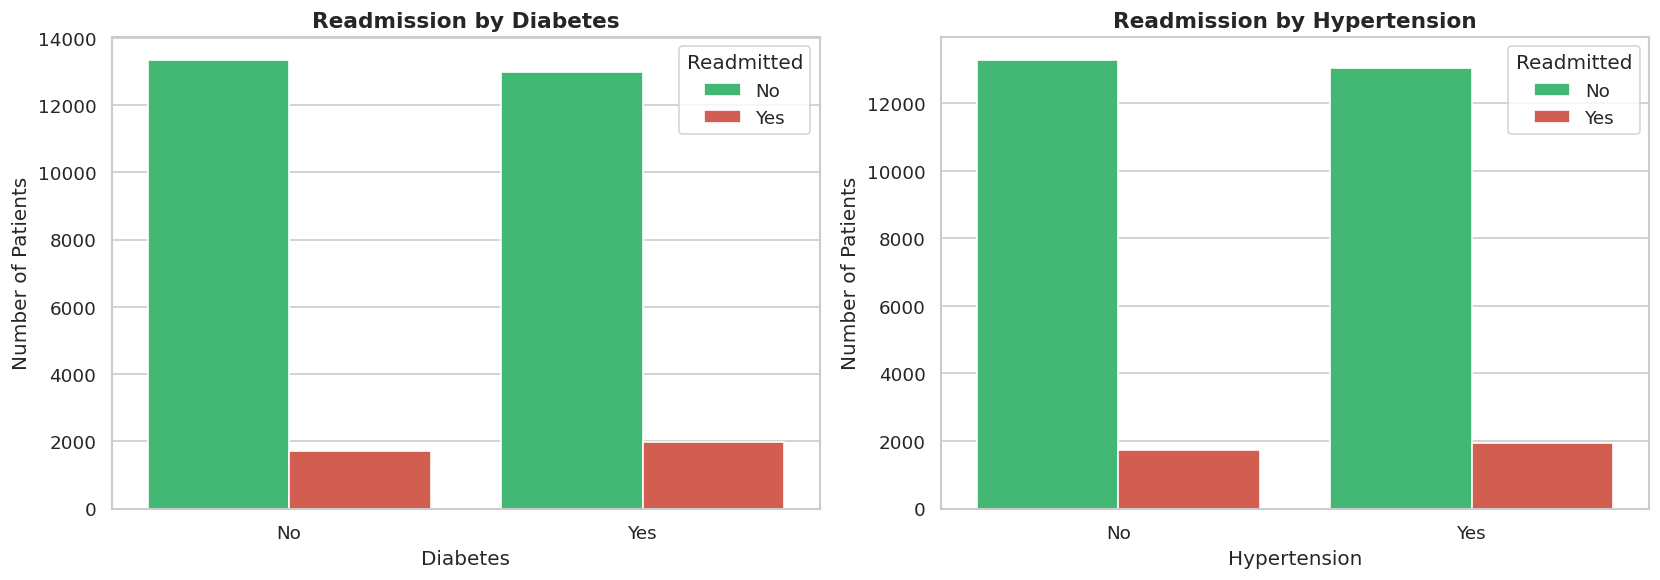

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title_label in zip(
        axes,
        ["diabetes", "hypertension"],
        ["Diabetes", "Hypertension"]):
    tmp = df.groupby([col, "readmitted_30_days"]).size().reset_index(name="count")
    sns.barplot(x=col, y="count", hue="readmitted_30_days", data=tmp,
                palette={"Yes": "#E74C3C", "No": "#2ECC71"}, ax=ax)
    ax.set_title(f"Readmission by {title_label}", fontsize=13, fontweight="bold")
    ax.set_xlabel(title_label)
    ax.set_ylabel("Number of Patients")
    ax.legend(title="Readmitted")

plt.tight_layout()
plt.show()

This cell generates two bar plots, one showing readmission rates by diabetes status and another by hypertension status.
It helps to identify if these conditions are associated with higher readmission likelihood.

## 7.7 Medication Count by Readmission Status (Box Plot)

/tmp/ipykernel_3860/2360379863.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="readmitted_30_days", y="medication_count", data=df,


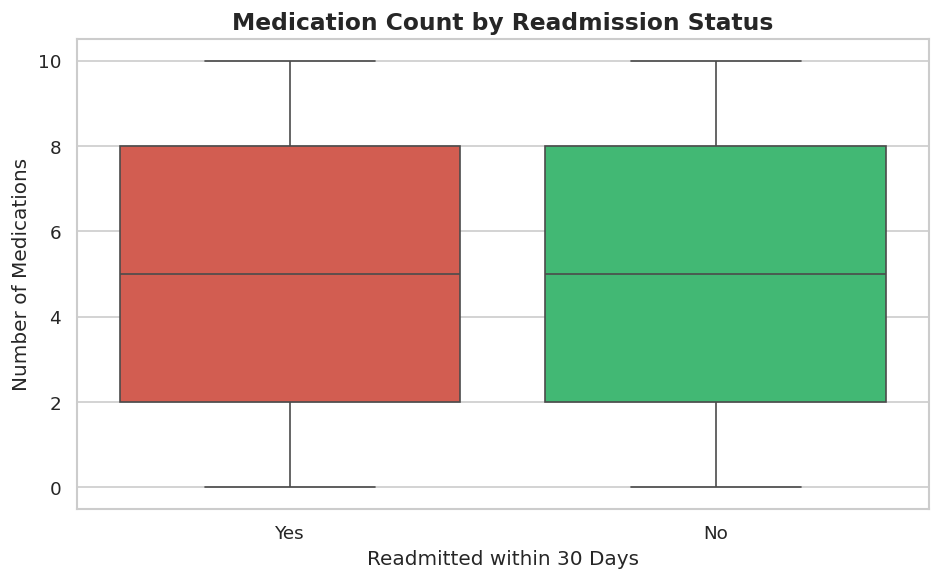

In [55]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="readmitted_30_days", y="medication_count", data=df,
            palette={"Yes": "#E74C3C", "No": "#2ECC71"})
plt.title("Medication Count by Readmission Status", fontsize=14, fontweight="bold")
plt.xlabel("Readmitted within 30 Days")
plt.ylabel("Number of Medications")
plt.tight_layout()
plt.show()

This code creates a box plot to compare the distribution of medication counts for readmitted versus non-readmitted patients.
It reveals potential differences in medication usage based on readmission status.

## 7.8 Distribution of All Numerical Features

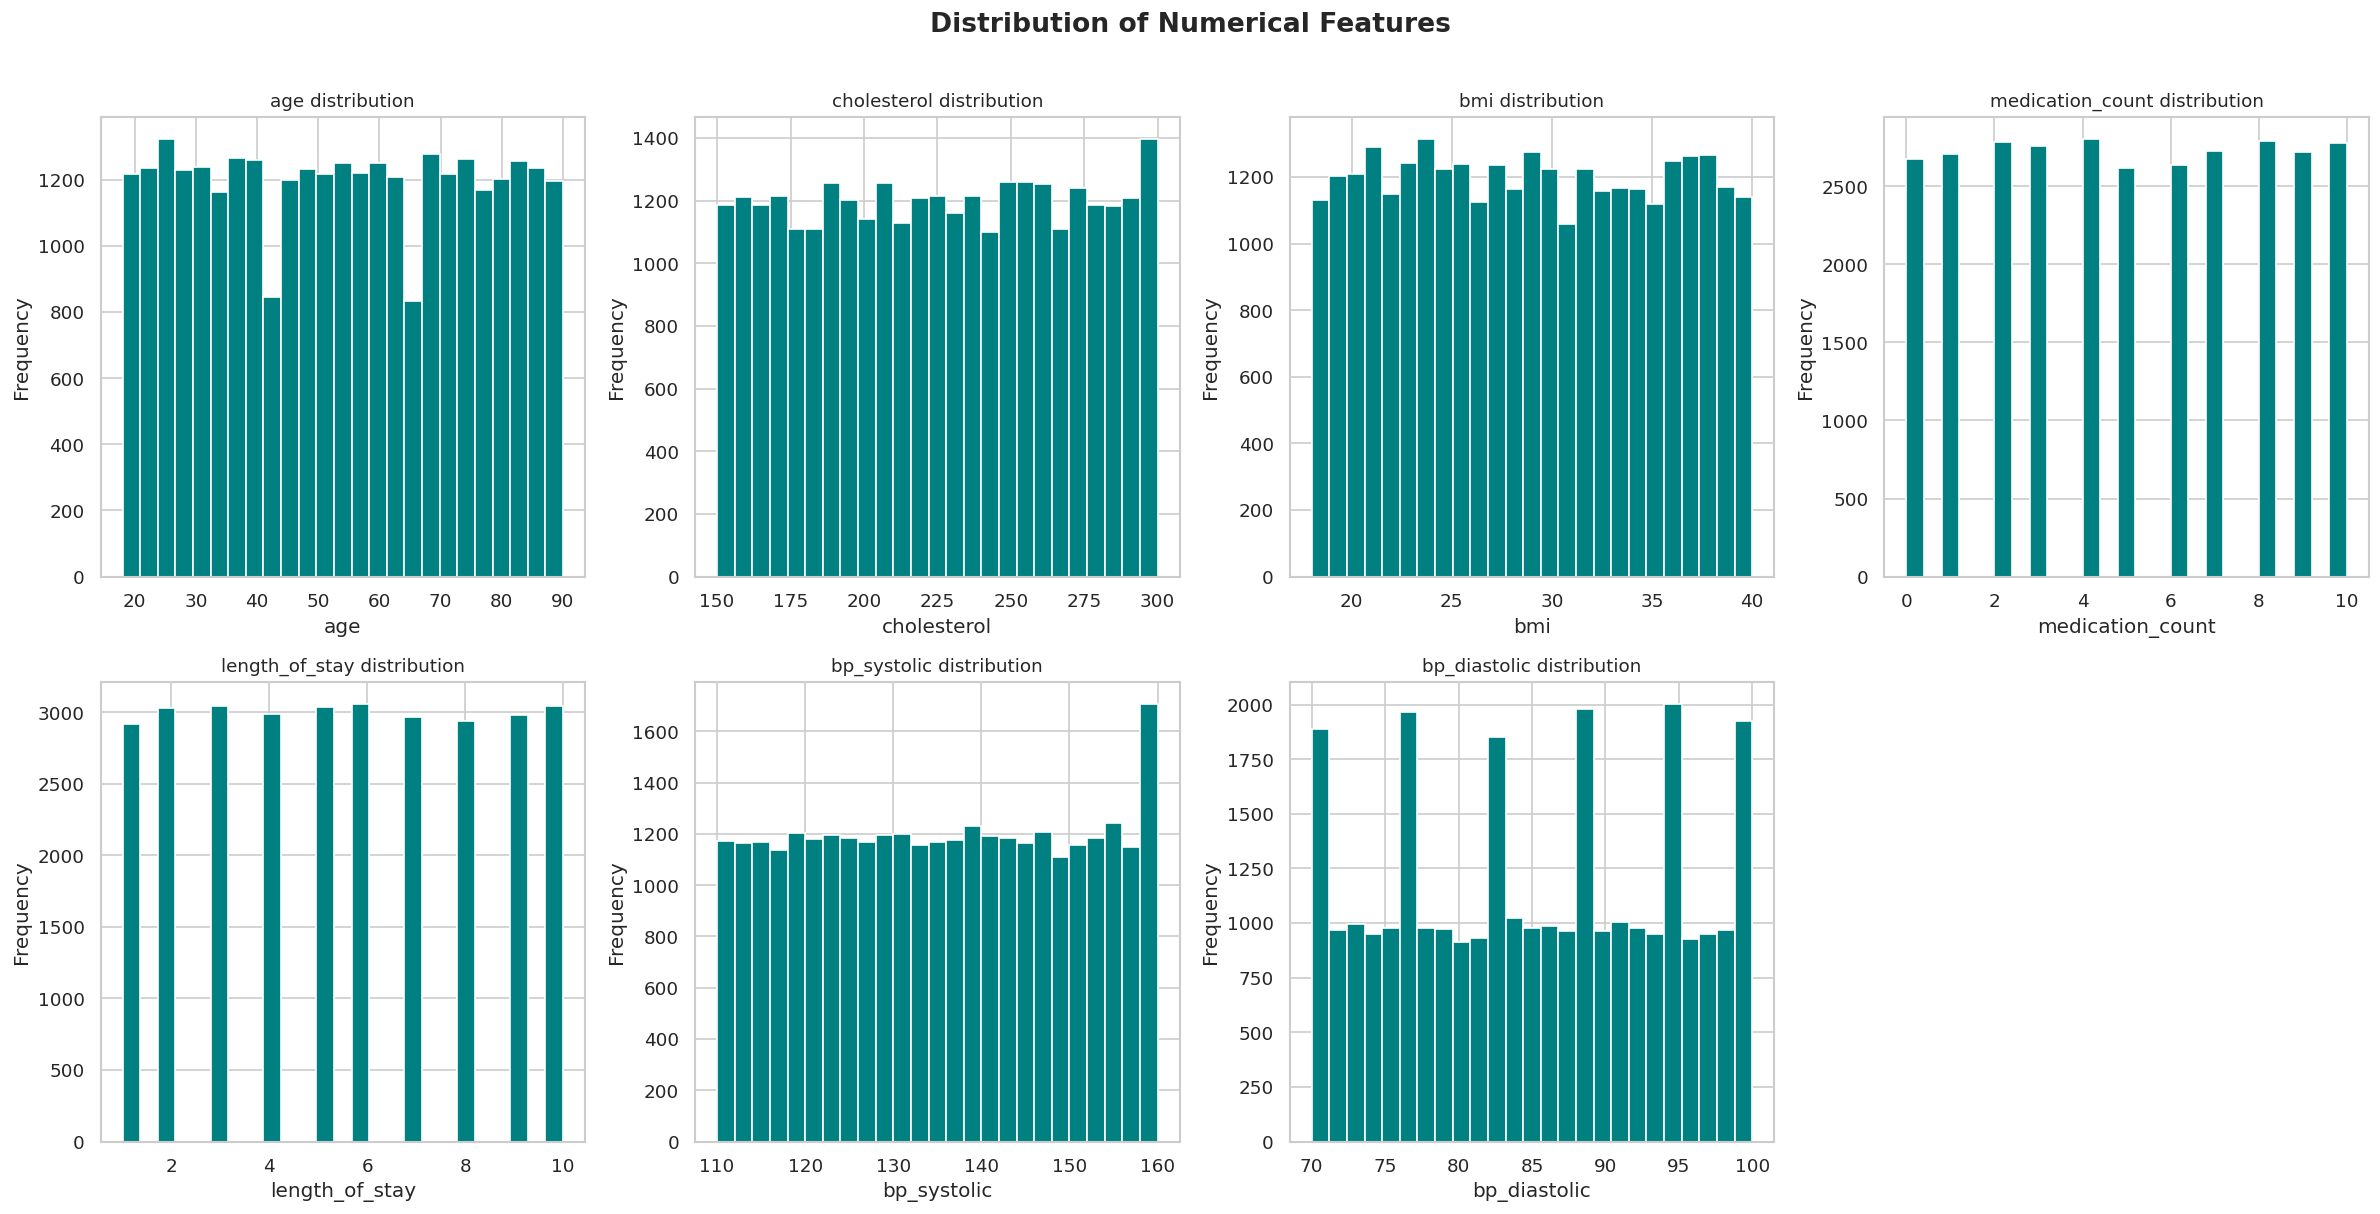

In [56]:
num_cols = ["age", "cholesterol", "bmi", "medication_count",
           "length_of_stay", "bp_systolic", "bp_diastolic"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    df[col].hist(ax=axes[i], edgecolor="white", color="teal", bins=25)
    axes[i].set_title(f"{col} distribution", fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide the last empty subplot
axes[-1].set_visible(False)
plt.suptitle("Distribution of Numerical Features", fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

This cell generates histograms for various numerical features to visualize their distributions.
It provides insights into the spread and patterns of individual numerical variables.

## 7.9 Readmitted Patients by Discharge Destination (Pie Chart)

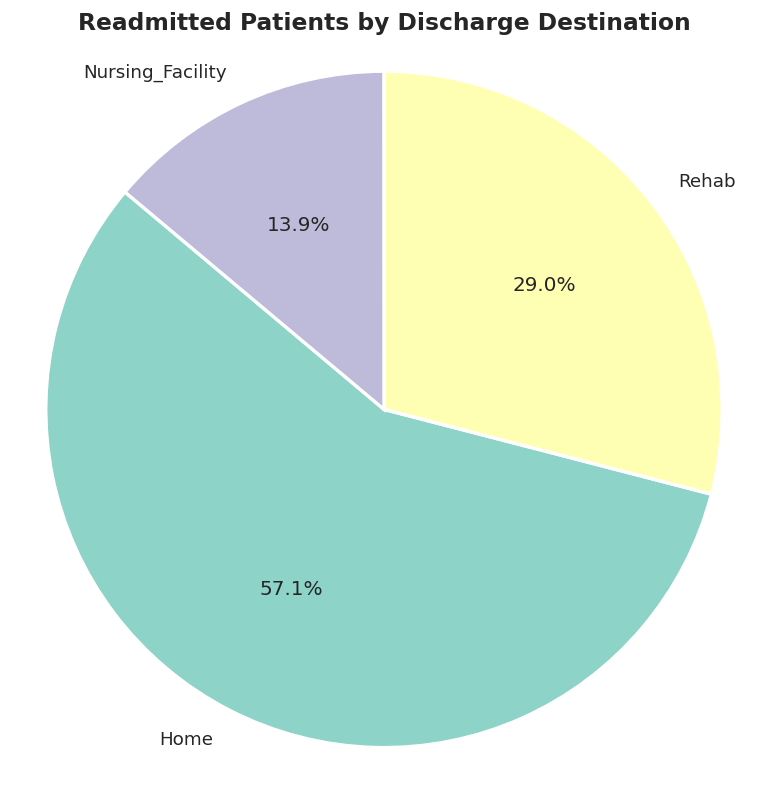

In [57]:
readmitted_df = df[df["readmitted_30_days"] == "Yes"]
dest_readmit = readmitted_df["discharge_destination"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(dest_readmit, labels=dest_readmit.index, autopct="%1.1f%%",
        startangle=140, colors=sns.color_palette("Set3"),
        wedgeprops={"edgecolor": "white", "linewidth": 2})
plt.title("Readmitted Patients by Discharge Destination", fontsize=14, fontweight="bold")
plt.axis("equal")
plt.show()

This code creates a pie chart specifically for patients who were readmitted within 30 days.
It shows the proportion of readmitted patients across different discharge destinations.

## 7.10 Cholesterol vs Systolic Blood Pressure (coloured by Age Group)

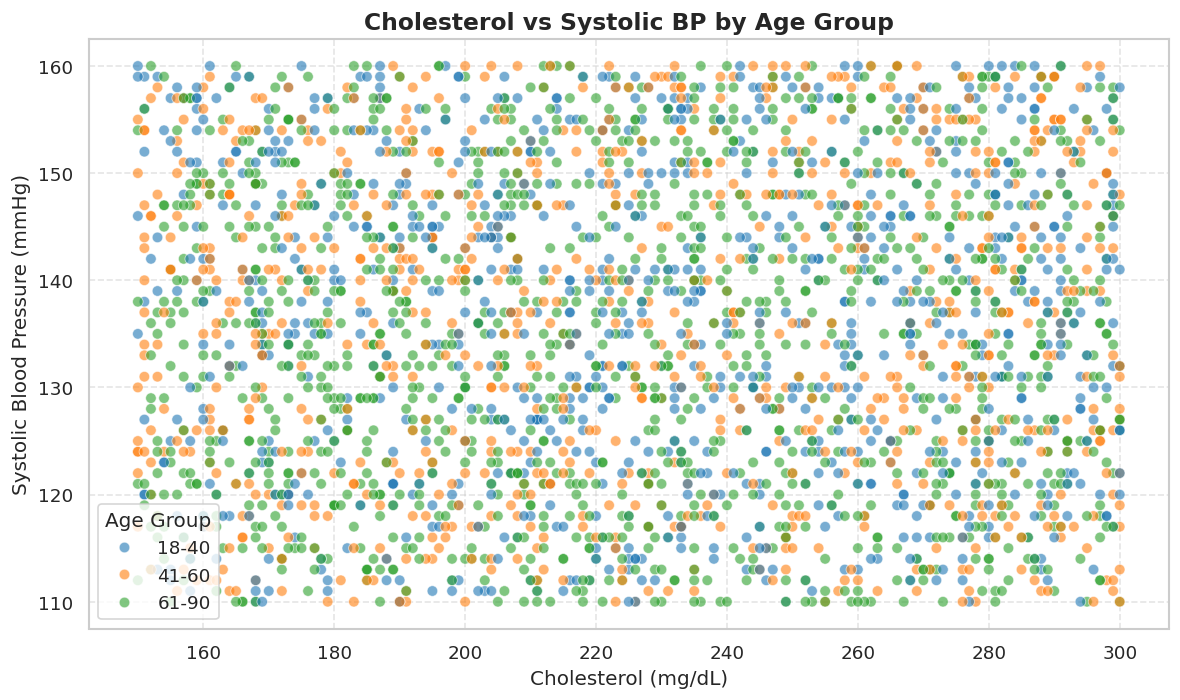

In [58]:
df["age_group"] = pd.cut(df["age"], bins=[17, 40, 60, 90], labels=["18-40", "41-60", "61-90"])

plt.figure(figsize=(10, 6))
sns.scatterplot(x="cholesterol", y="bp_systolic",
                hue="age_group", data=df.sample(3000, random_state=1),
                alpha=0.6, s=40, palette="tab10")
plt.title("Cholesterol vs Systolic BP by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Cholesterol (mg/dL)")
plt.ylabel("Systolic Blood Pressure (mmHg)")
plt.legend(title="Age Group")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

This cell generates a scatter plot comparing cholesterol levels and systolic blood pressure, colored by age group.
It explores the relationship between these factors across different patient age segments.

# **8. Decision Tree Classifier**


In [68]:
le = LabelEncoder()
df["readmitted_encoded"] = le.fit_transform(df["readmitted_30_days"])  # Yes=1, No=0

X_dt = df[["age", "bmi", "length_of_stay", "medication_count"]]
y_dt = df["readmitted_encoded"]

dtree = DecisionTreeClassifier(max_depth=3, random_state=42)
dtree.fit(X_dt, y_dt)
print("Decision Tree Classifier trained successfully!")
print(f"   Features : {X_dt.columns.tolist()}")
print(f"   Target   : readmitted_30_days  (0=No, 1=Yes)")

Decision Tree Classifier trained successfully!
   Features : ['age', 'bmi', 'length_of_stay', 'medication_count']
   Target   : readmitted_30_days  (0=No, 1=Yes)


This cell prepares data for a Decision Tree Classifier and then trains the model.
It uses `age`, `bmi`, `length_of_stay`, and `medication_count` to predict readmission.

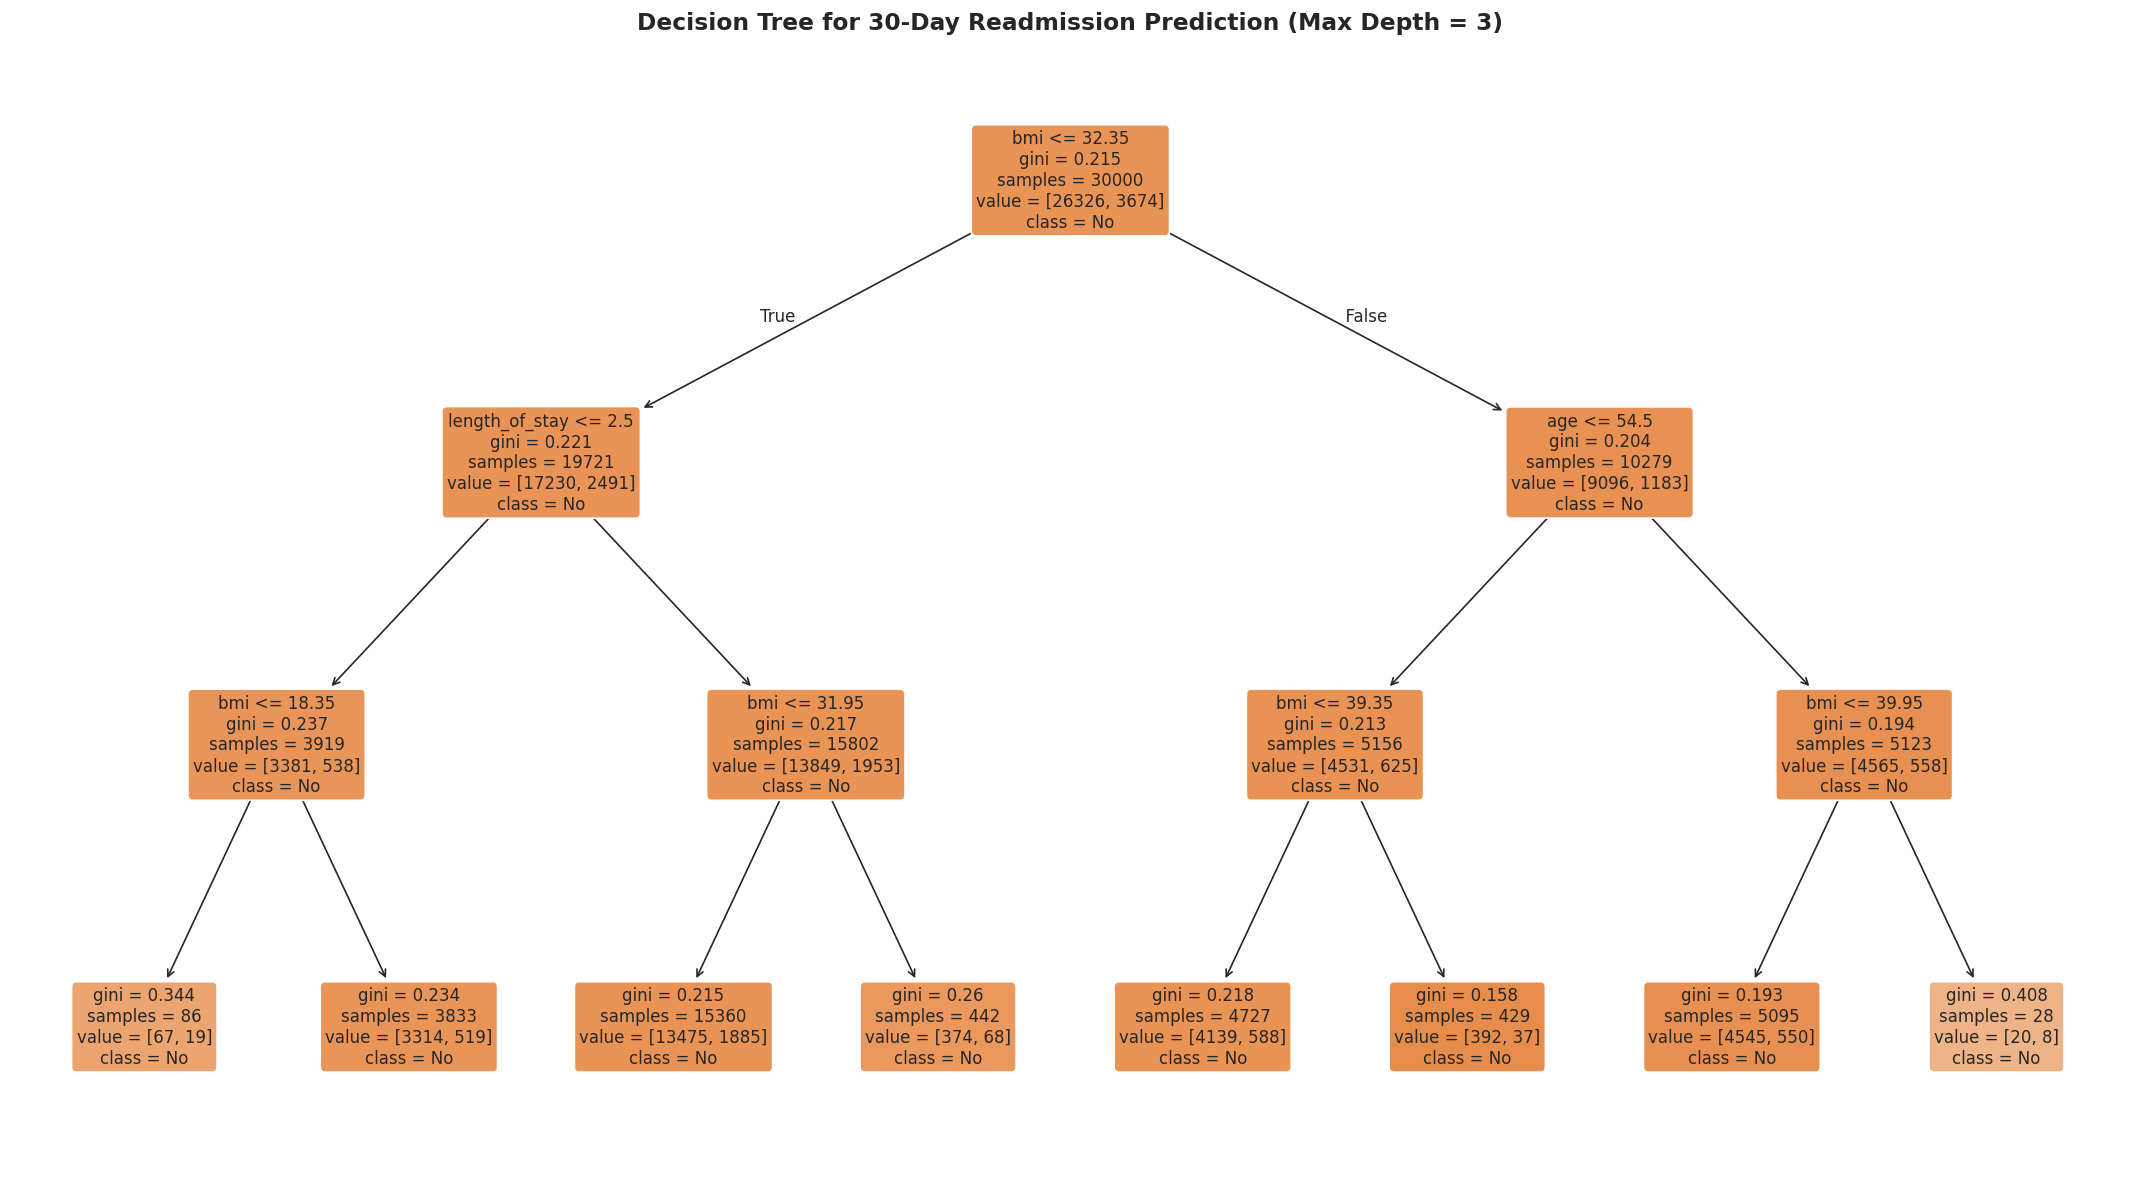

In [75]:
plt.figure(figsize=(18, 10))
tree.plot_tree(dtree,
               feature_names=X_dt.columns.tolist(),
               class_names=le.classes_,
               filled=True, rounded=True, fontsize=10)
plt.title("Decision Tree for 30-Day Readmission Prediction (Max Depth = 3)",
          fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

This code visualizes the trained Decision Tree Classifier.
The tree structure helps to understand the decision rules used for readmission prediction.

## 8.1 Training Model — Sample Prediction

In [61]:
new_patient = pd.DataFrame({
    "age": [65],
    "bmi": [30.5],
    "length_of_stay": [7],
    "medication_count": [8]
})

pred_encoded = dtree.predict(new_patient)
pred_label   = le.inverse_transform(pred_encoded)
print(f"Predicted 30-day readmission for new patient: {pred_label[0]}")

Predicted 30-day readmission for new patient: No


This cell demonstrates how to use the trained Decision Tree Classifier to predict readmission for a new, hypothetical patient.
It outputs the predicted 30-day readmission status.

# **9. Logistic Regression**



In [72]:
X_lr = df[["length_of_stay", "medication_count"]]
y_lr = df["readmitted_encoded"]

X_train, X_test, y_train, y_test = train_test_split(X_lr, y_lr, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

lr_model = LogisticRegression(max_iter=300)
lr_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=300)

This cell prepares data, splits it into training and testing sets, scales numerical features, and trains a Logistic Regression model.
The model predicts readmission based on 'length_of_stay' and 'medication_count'.

# **10. Predictive Model Evaluation**

In [63]:
predictions = lr_model.predict(X_test_scaled)
acc = accuracy_score(y_test, predictions)
print(f"Accuracy: {acc:.4f}  ({acc*100:.2f}%)")
print()
print(classification_report(y_test, predictions, target_names=le.classes_))

Accuracy: 0.8718  (87.18%)

              precision    recall  f1-score   support

          No       0.87      1.00      0.93      5231
         Yes       0.00      0.00      0.00       769

    accuracy                           0.87      6000
   macro avg       0.44      0.50      0.47      6000
weighted avg       0.76      0.87      0.81      6000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


This code evaluates the Logistic Regression model's performance using accuracy and a classification report.
It provides metrics such as precision, recall, and F1-score for each class.

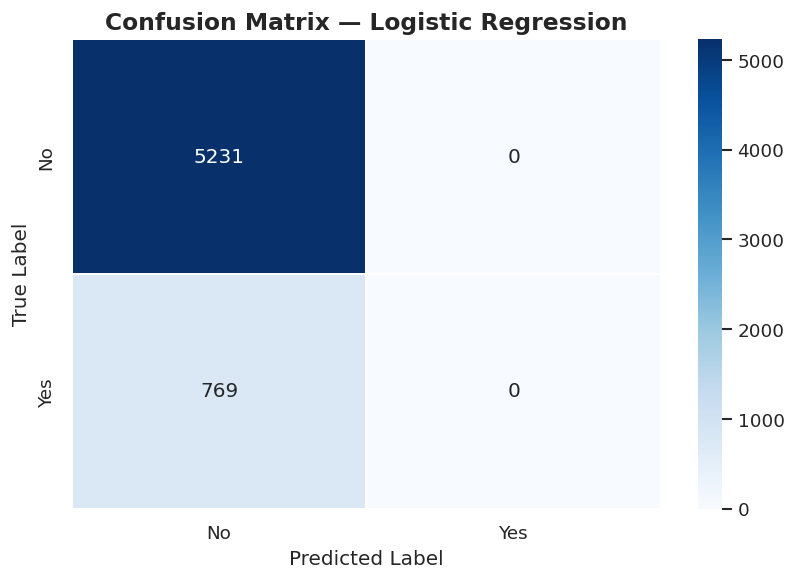

In [64]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=1)
plt.title("Confusion Matrix — Logistic Regression", fontsize=14, fontweight="bold")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

This cell generates and displays a confusion matrix for the Logistic Regression model's predictions.
It visually represents the number of true positives, true negatives, false positives, and false negatives.

## 10.1 Single Patient Prediction (Logistic Regression)

In [65]:
single = scaler.transform([[6, 8]])   # length_of_stay=6, medication_count=8
pred_single = lr_model.predict(single)
print(f"Predicted readmission (LOS=6, Meds=8): {le.inverse_transform(pred_single)[0]}")

Predicted readmission (LOS=6, Meds=8): No


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


This code demonstrates how to use the trained Logistic Regression model to predict readmission for a single new patient.
It provides a prediction based on the patient's length of stay and medication count.